# Fine-tune YOLO11 for PPE Detection (Đồ bảo hộ)
Notebook train mô hình nhận diện đồ bảo hộ trên Google Colab bằng **YOLO11** (Ultralytics).

**Lưu ý:** Bật GPU trước khi chạy → Runtime → Change runtime type → Hardware accelerator: **GPU (T4)**.

In [1]:
!pip install ultralytics roboflow imagehash
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 6960.6/8062.4 GB disk)


## 1. Tải Dataset từ Roboflow
API key được nhập lúc chạy (không lưu cứng trong code để tránh lộ key).
Đổi `VERSION` cho khớp phiên bản dataset bạn muốn dùng.

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Ni608AITMTSqxmU3H9Ps")
project = rf.workspace("anhs-workspace-us2tl").project("ppe-detection-pamtd")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-Detection-1 in yolov11:: 100%|██████████| 2665/2665 [00:00<00:00, 7989.38it/s]


## 2. Kiểm tra TRÙNG ẢNH giữa train / valid / test (data leakage)
Nếu ảnh train xuất hiện lại trong tập valid/test thì điểm mAP sẽ bị **thổi phồng giả tạo** — model trông giỏi hơn thực tế.

Cell này dùng **perceptual hash (pHash)** nên bắt được cả ảnh bị resize / nén lại / đổi tên, không chỉ ảnh giống hệt byte-by-byte.
- `distance = 0` → trùng gần như tuyệt đối
- `distance <= 5` → rất giống (nhiều khả năng là cùng một ảnh sau augment)

In [3]:
import os, glob
from PIL import Image
import imagehash

BASE = dataset.location
SPLITS = ["train", "valid", "test"]
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
THRESHOLD = 5  # hamming distance coi là 'trùng/gần trùng'

def list_images(split):
    d = os.path.join(BASE, split, "images")
    if not os.path.isdir(d):
        return []
    return [p for p in glob.glob(os.path.join(d, "*")) if p.lower().endswith(IMG_EXT)]

# Tính pHash cho từng split
hashes = {}
for s in SPLITS:
    imgs = list_images(s)
    hashes[s] = []
    for p in imgs:
        try:
            hashes[s].append((os.path.basename(p), imagehash.phash(Image.open(p).convert("RGB"))))
        except Exception as e:
            print("Lỗi đọc ảnh:", p, e)
    print(f"{s:6s}: {len(hashes[s])} ảnh")

def compare(a, b):
    dups = []
    for na, ha in hashes[a]:
        for nb, hb in hashes[b]:
            dist = ha - hb
            if dist <= THRESHOLD:
                dups.append((na, nb, dist))
    return dups

print("\n===== KẾT QUẢ KIỂM TRA TRÙNG ẢNH =====")
total = 0
for a, b in [("train", "valid"), ("train", "test"), ("valid", "test")]:
    if not hashes[a] or not hashes[b]:
        continue
    dups = compare(a, b)
    total += len(dups)
    print(f"\n[{a} vs {b}] -> {len(dups)} cặp trùng/gần trùng")
    for na, nb, dist in dups[:30]:
        print(f"   dist={dist}: {a}/{na}  <->  {b}/{nb}")
    if len(dups) > 30:
        print(f"   ... và {len(dups) - 30} cặp nữa")

if total == 0:
    print("\n[OK] KHONG phat hien trung anh giua cac tap. Dataset sach, mAP dang tin.")
else:
    print(f"\n[CANH BAO] Phat hien {total} cap trung/gan trung. Nen xoa anh trung khoi valid/test roi train lai.")

train : 942 ảnh
valid : 138 ảnh
test  : 250 ảnh

===== KẾT QUẢ KIỂM TRA TRÙNG ẢNH =====

[train vs valid] -> 0 cặp trùng/gần trùng

[train vs test] -> 0 cặp trùng/gần trùng

[valid vs test] -> 0 cặp trùng/gần trùng

[OK] KHONG phat hien trung anh giua cac tap. Dataset sach, mAP dang tin.


## 2b. Dọn ảnh rò rỉ khỏi valid/test
Chạy SAU Cell 2 (cần biến `hashes`, `THRESHOLD`, `BASE`). Luôn **giữ bản ở train**, chỉ xoá bản trùng ở valid/test cùng file nhãn `.txt`.
Sau khi dọn, chạy lại Cell 2 để xác nhận còn 0 cặp trùng rồi mới train.

In [4]:
import os

# Gom cac ban can xoa: luon xoa o split DUNG SAU (b), giu lai ban o train
to_remove = set()
for a, b in [("train", "valid"), ("train", "test"), ("valid", "test")]:
    if not hashes.get(a) or not hashes.get(b):
        continue
    for na, ha in hashes[a]:
        for nb, hb in hashes[b]:
            if ha - hb <= THRESHOLD:
                to_remove.add((b, nb))

removed = 0
for split, name in to_remove:
    ip = os.path.join(BASE, split, "images", name)
    lp = os.path.join(BASE, split, "labels", os.path.splitext(name)[0] + ".txt")
    for f in (ip, lp):
        if os.path.exists(f):
            os.remove(f)
    removed += 1
    print("Da xoa:", split, "/", name)

print(f"\nDa xoa {removed} anh ro ri khoi valid/test. Chay lai Cell 2 de xac nhan con 0 cap trung.")


Da xoa 0 anh ro ri khoi valid/test. Chay lai Cell 2 de xac nhan con 0 cap trung.


## 3. Training với YOLO11
`yolo11s.pt` (bản Small), fine-tune cho PPE.

**Quan trọng — BẬT augmentation mặc định:** ở thử nghiệm ban đầu khi tắt hết augmentation, model overfit rất sớm (best ~epoch 8, `val_loss` tăng dần) và mAP@0.5 test chỉ ~0.73. Khi dùng augmentation mặc định của Ultralytics, model học ổn định hơn, best lùi về ~epoch 47 và mAP@0.5 test đạt ~0.825. **Vì vậy KHÔNG tắt augmentation.**

- `epochs=150`, `imgsz=640`, `batch=16`
- `patience=50`: tự dừng sớm nếu 50 epoch liên tiếp không cải thiện.
- `seed=42`: cố định để kết quả lặp lại được.

In [5]:

model = YOLO('yolo11m.pt') 

yaml_path = f"{dataset.location}/data.yaml"


results = model.train(
    data=yaml_path,
    epochs=150,
    imgsz=800,           # Vẫn giữ nguyên 800 để soi vật thể nhỏ
    batch=16,            # Lưu ý: nếu GPU Kaggle báo lỗi Out of Memory (OOM), hãy giảm xuống batch=8
    patience=50,
    seed=42,
    name='yolo11_ppe_aug_medium', # Đổi tên run để không bị nhầm với bản trước
    device=[0, 1],
)

# Lưu đường dẫn THẬT của run vừa train
RUN = str(model.trainer.save_dir)
print('Run dir:', RUN)


Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/PPE-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yo

## 4. Xem kết quả training
Biểu đồ loss/mAP và confusion matrix.

RUN = /kaggle/working/runs/detect/yolo11_ppe_aug_medium


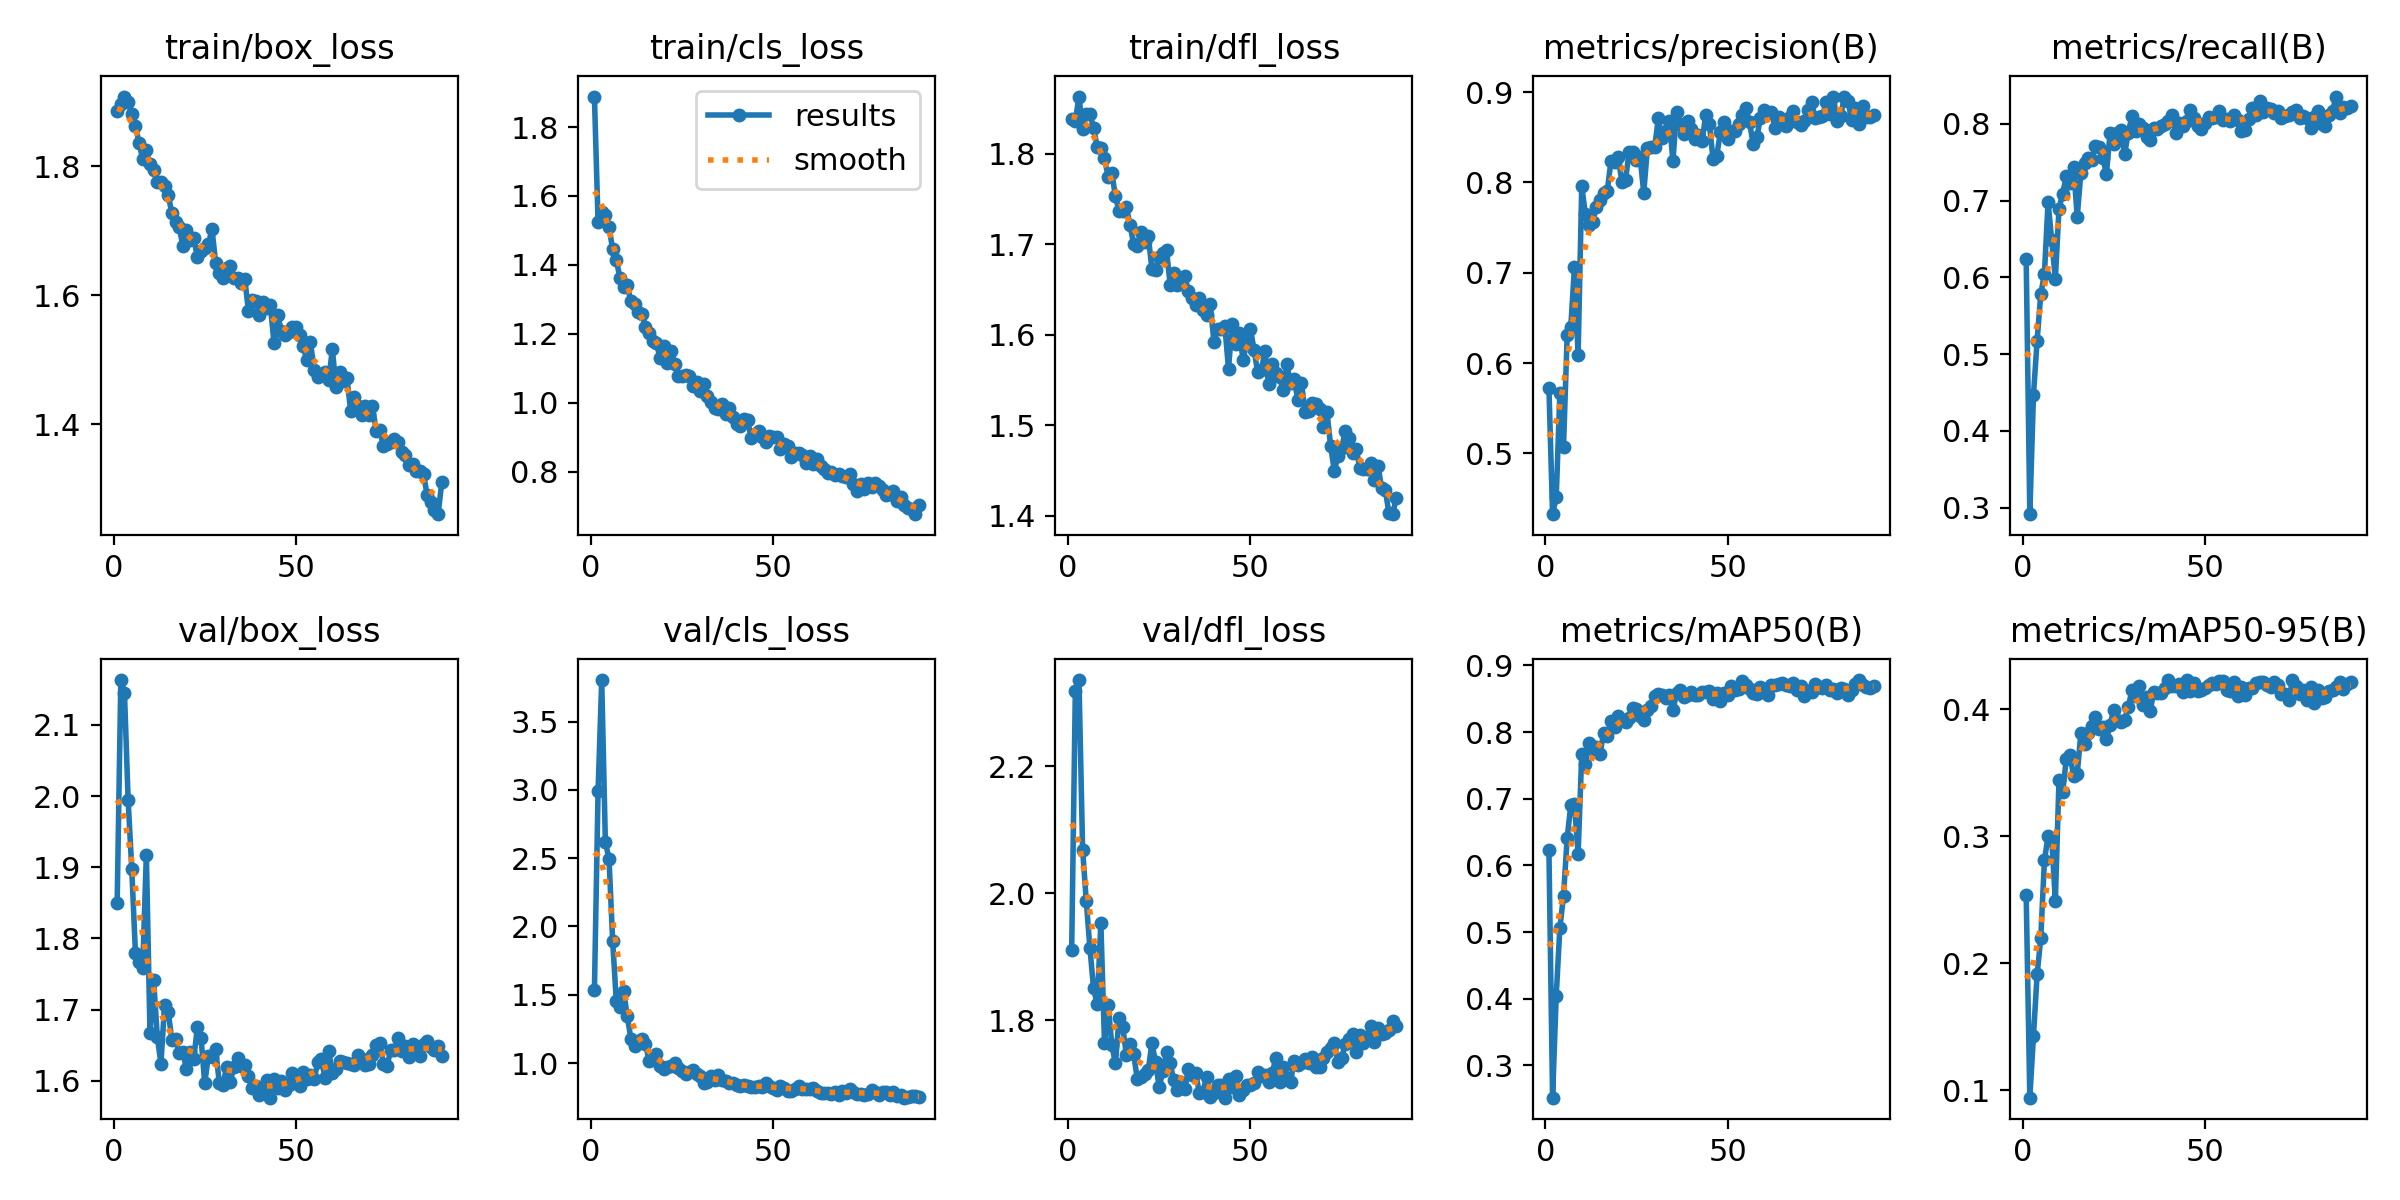

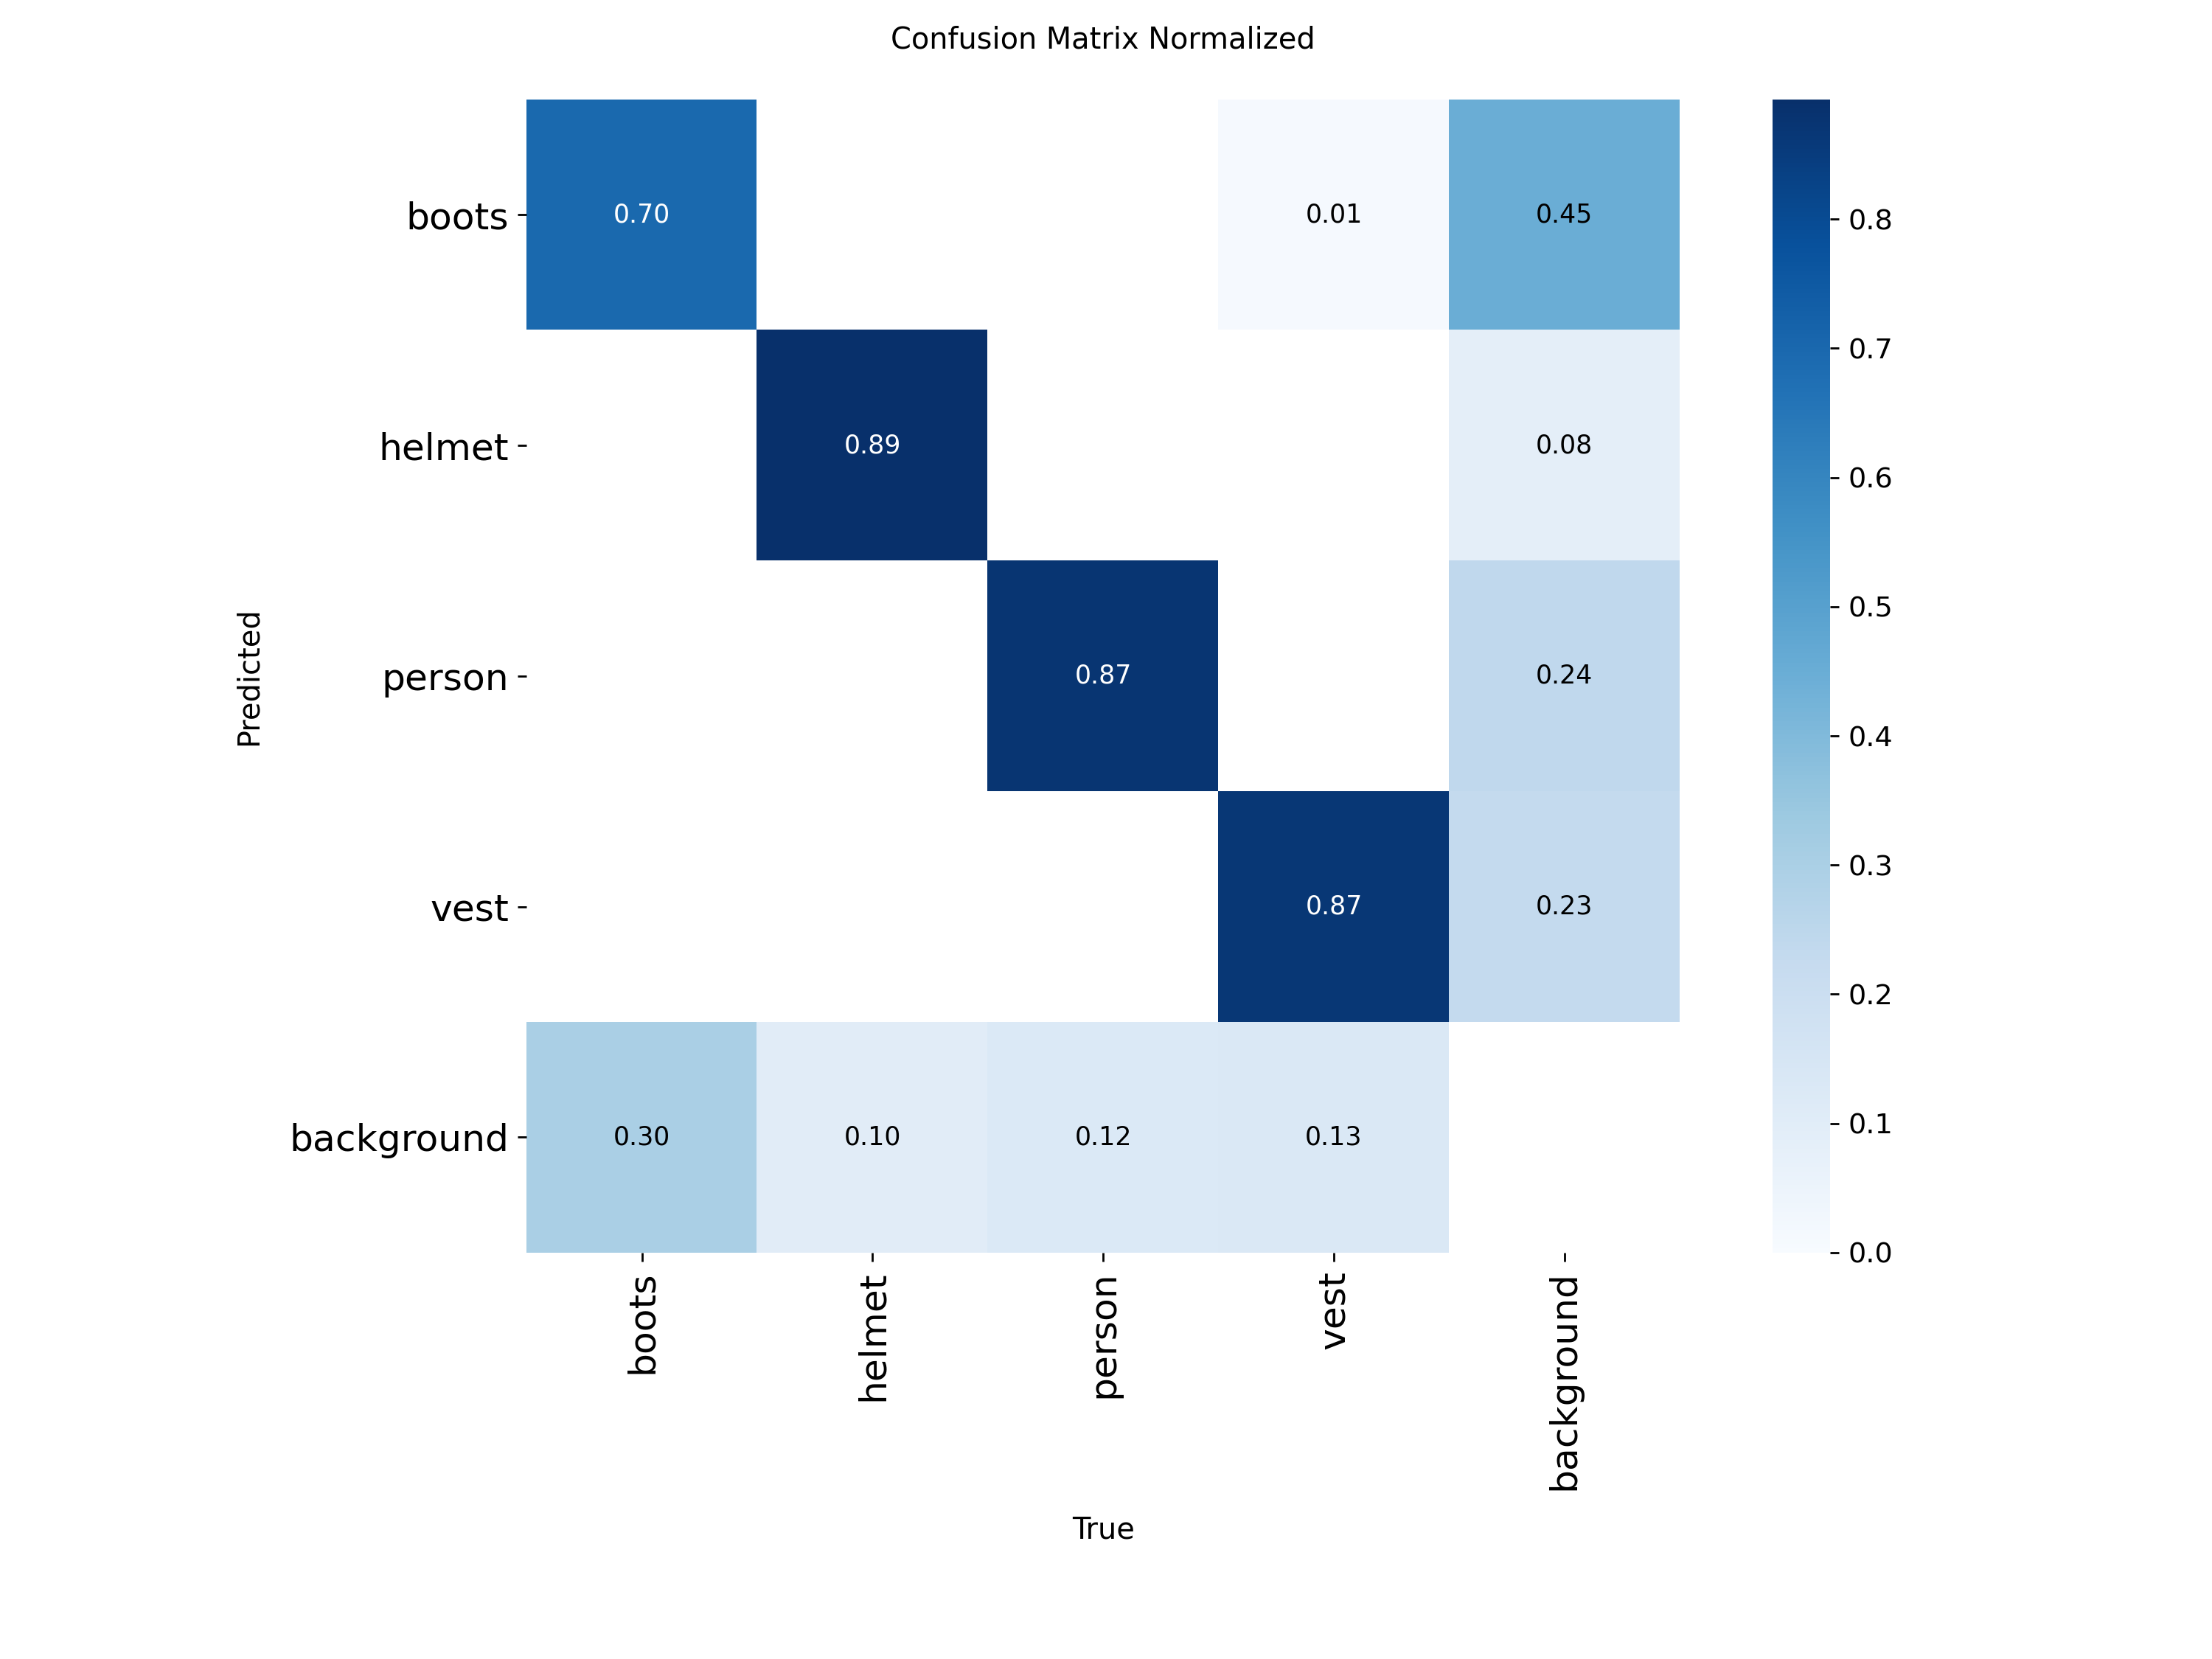

In [6]:
from pathlib import Path
from IPython.display import Image, display

# Nếu chạy lại sau khi restart kernel (chưa có biến RUN) thì tự tìm run mới nhất
if 'RUN' not in globals():
    runs = sorted(Path('runs/detect').glob('yolo11_ppe_aug*'), key=lambda p: p.stat().st_mtime)
    assert runs, "Khong tim thay run nao. Can chay lai cell training (cell 3)."
    RUN = str(runs[-1])
print('RUN =', RUN)

display(Image(filename=f'{RUN}/results.png'))
display(Image(filename=f'{RUN}/confusion_matrix_normalized.png'))

## 5. Đánh giá lại trên tập TEST (nếu có)
Train log chỉ báo kết quả trên `valid`. Chạy thêm trên `test` để có con số khách quan.

In [7]:
best = YOLO(f'{RUN}/weights/best.pt')
metrics = best.val(data=yaml_path, split='test')  # doi thanh 'val' neu khong co tap test
print('mAP50-95:', metrics.box.map)
print('mAP50   :', metrics.box.map50)

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 21.2±16.8 MB/s, size: 68.1 KB)
val: Scanning /kaggle/working/PPE-Detection-1/test/labels... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 599.7it/s 0.4s0.0s
val: New cache created: /kaggle/working/PPE-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.3it/s 12.6s0.8s
                   all        250       2595      0.842      0.773      0.826      0.401
                 boots        243        849      0.792      0.623      0.712      0.264
                helmet        211        611      0.911      0.836      0.894      0.406
                person        250        729      0.892      0.852      0.904      0.518
                  vest        153        406 

## 6. Predict thử vài ảnh (xem model sai ở đâu)


0: 800x800 1 boots, 2 helmets, 2 persons, 2 vests, 44.5ms
1: 800x800 10 bootss, 10 helmets, 8 persons, 5 vests, 44.5ms
2: 800x800 3 bootss, 2 helmets, 2 persons, 2 vests, 44.5ms
3: 800x800 2 bootss, 2 helmets, 2 persons, 1 vest, 44.5ms
4: 800x800 5 bootss, 7 helmets, 7 persons, 8 vests, 44.5ms
5: 800x800 1 boots, 1 person, 1 vest, 44.5ms
Speed: 4.4ms preprocess, 44.5ms inference, 1.0ms postprocess per image at shape (1, 3, 800, 800)
Results saved to /kaggle/working/runs/detect/predict
Anh ket qua da luu tai: /kaggle/working/runs/detect/predict


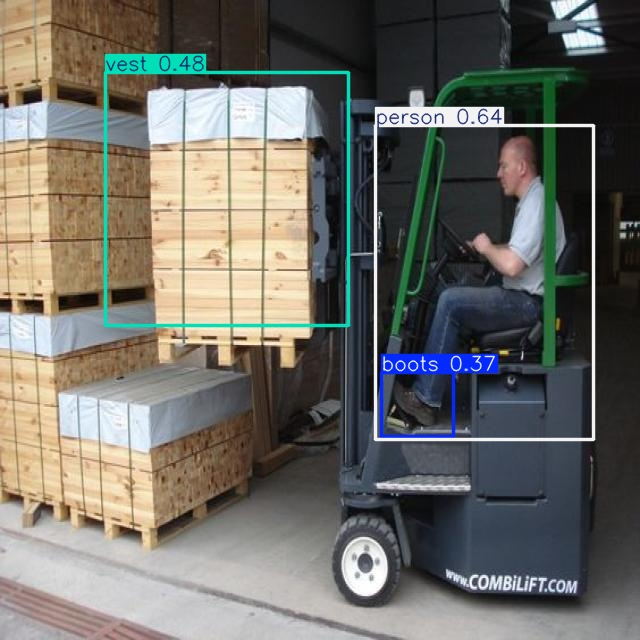

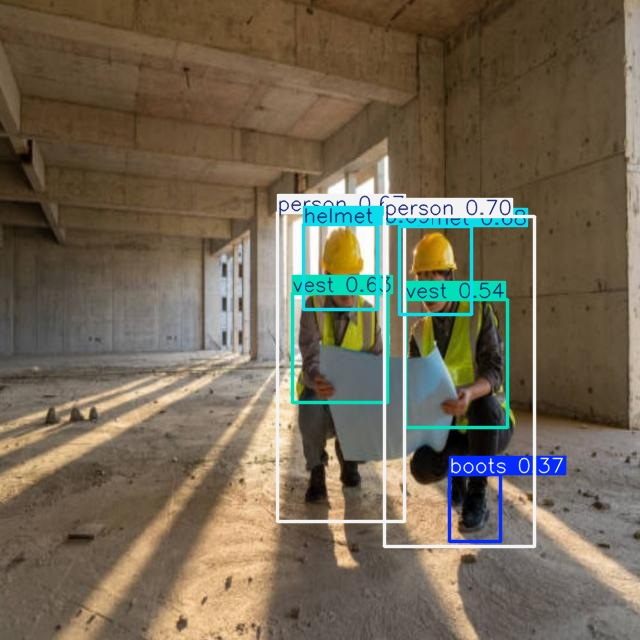

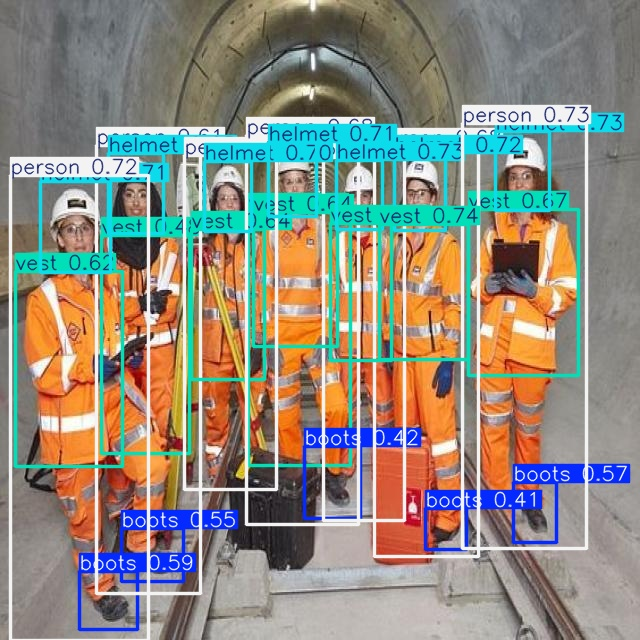

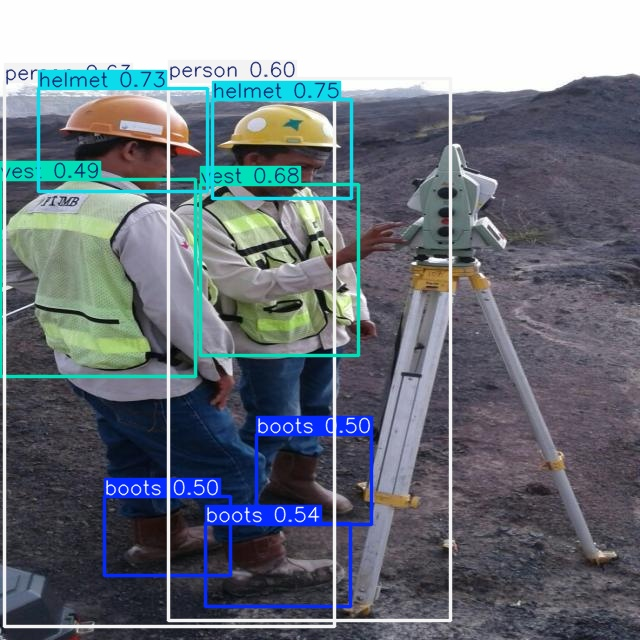

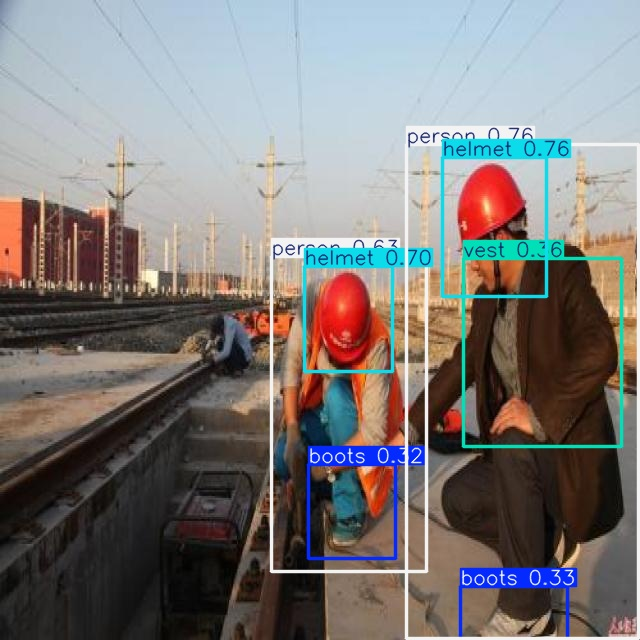

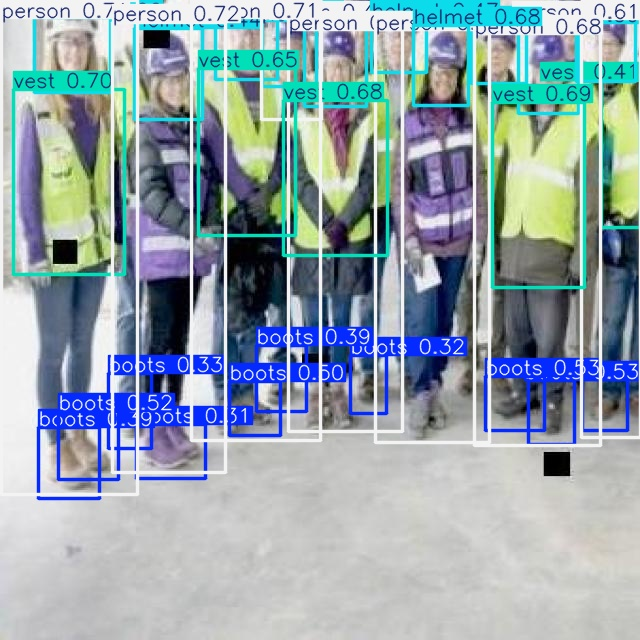

In [8]:
import glob
test_imgs = glob.glob(f'{dataset.location}/test/images/*')[:6]
if not test_imgs:
    test_imgs = glob.glob(f'{dataset.location}/valid/images/*')[:6]

# conf thap (0.3) de bat duoc ca 'boots' (class nay confidence thuong thap)
res = best.predict(test_imgs, conf=0.3, save=True)
print('Anh ket qua da luu tai:', res[0].save_dir)

from IPython.display import Image as IPyImage, display
for p in glob.glob(f'{res[0].save_dir}/*')[:6]:
    display(IPyImage(filename=p))

## 7. Tải file weights về máy
Tải `best.pt` về, đổi tên `ppe_yolo11.pt` và bỏ vào `VisionGate/AI_Core/models/`.

In [9]:
import shutil
src = f'{RUN}/weights/best.pt'

try:
    # Google Colab: tai thang ve may
    from google.colab import files
    shutil.copy(src, 'ppe_yolo11.pt')
    files.download('ppe_yolo11.pt')
except ImportError:
    # Kaggle: copy ra /kaggle/working roi tai o tab Output (Data) ben phai
    from IPython.display import FileLink, display
    shutil.copy(src, '/kaggle/working/ppe_yolo11.pt')
    print('Da luu /kaggle/working/ppe_yolo11.pt -> tai ve o tab Output (Data).')
    display(FileLink('ppe_yolo11.pt'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# === 8. Deploy model len Roboflow (tuy chon) ===
# model_path tro toi THU MUC RUN (KHONG them /weights) -> Roboflow tu noi 'weights/best.pt'
from roboflow import Roboflow

rf = Roboflow(api_key="Ni608AITMTSqxmU3H9Ps")
project = rf.workspace("anhs-workspace-us2tl").project("ppe-detection-pamtd")
version = project.version(1)

version.deploy(model_type="yolov11", model_path=RUN)
print('Deploy xong. Xem o tab Models cua project tren Roboflow.')

loading Roboflow workspace...
loading Roboflow project...
An error occured when getting the model upload URL: This version already has a trained model. Please generate and train a new version in order to upload model to Roboflow.
Deploy xong. Xem o tab Models cua project tren Roboflow.
